# Convergence Simulation — UCB vs Random Search from Cold Start

Monte Carlo simulation comparing UCB acquisition against random baseline from a cold start (zero historical runs).
Uses an accuracy-oriented Random Forest oracle (trained on all 3,400 yelp2018 MF runs) as simulated ground truth.

**Question:** From a cold start on a 20K-cell categorical space with ~5 dimensions, how many UCB-guided runs to reach ESM 99% vs. random search?

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from src.visualization import set_themes
from src.utils import get_kernel_id
from src.utils.config import parse_score_metric, Log10Transformer, model_based_parse_parameters, parse_parameters
from src.utils.styled_tables import data_preview_styled
from IPython.display import Markdown

from typing import List
import io
import contextlib
from tqdm import tqdm

set_themes()
pl.Config.set_tbl_rows(20)

polars.config.Config

## Configuration

Define the target metric and the discrete hyperparameter space to enumerate over.

In [2]:
run_summary_file = "wandb/summary.parquet"

target_spec = "epoch/test_recall@20"
parsed_target = parse_score_metric(target_spec)
target_metric = "target"
beta = 4.0

feature_names = [
    "embedding_dimension",
    "shuffle",
    "l1_regularization",
    "l2_regularization",
    "embedding_dropout_rate",
]

## Data Loading

Load completed runs from the local parquet cache produced by `wandb/sync.py`.

In [3]:
experiment_runs = pl.read_parquet(run_summary_file)
experiment_runs = experiment_runs.filter(pl.col("model") == "matrix_factorization")

score_expression = sum(pl.col(m) * w for m, w in parsed_target.items())
experiment_runs = experiment_runs.with_columns(
    score_expression.list.max().alias(target_metric)
)

parameter_space = {}
for col in feature_names:
    unique_vals = sorted(experiment_runs[col].drop_nulls().unique().to_list())
    if col == "shuffle":
        unique_vals = [bool(v) for v in unique_vals]
    parameter_space[col] = unique_vals

total_space_size = 1
for values in parameter_space.values():
    total_space_size *= len(values)

print(f"Loaded {len(experiment_runs):,} runs")
print(f"Total joint parameter space: {total_space_size:,} configurations")
for col, vals in parameter_space.items():
    print(f"  {col}: {vals}")

Loaded 3,410 runs
Total joint parameter space: 20,000 configurations
  embedding_dimension: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
  shuffle: [False, True]
  l1_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  l2_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  embedding_dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


## Data Preparation

In [4]:
required_cols = feature_names + [target_metric]
full_dataframe = experiment_runs.select(required_cols).drop_nulls()

full_dataframe = full_dataframe.with_columns(pl.col("shuffle").cast(pl.Boolean))

full_features = full_dataframe.select(feature_names).to_numpy()
full_target = full_dataframe[target_metric].to_numpy()

print(f"Training samples: {len(full_target):,}")
print(f"Target range:  [{full_target.min():.4f}, {full_target.max():.4f}]")
print(f"Target mean:   {full_target.mean():.4f}  ±  {full_target.std():.4f}")

Training samples: 3,410
Target range:  [0.0004, 0.0511]
Target mean:   0.0217  ±  0.0193


## Full Parameter Grid

Build the complete 20,000-cell grid and tag cells as explored or unexplored based on the 3,410 completed runs.

In [5]:
all_combinations = list(itertools.product(*parameter_space.values()))
full_grid = pl.DataFrame(
    {col: [row[i] for row in all_combinations] for i, col in enumerate(feature_names)}
)
full_grid = full_grid.with_columns(pl.col("shuffle").cast(pl.Boolean))

explored_dataframe = (
    full_dataframe
    .group_by(feature_names)
    .agg(pl.col(target_metric).mean().alias(f"observed_{target_metric}"))
)
explored_keys = set(
    tuple(row) for row in explored_dataframe.select(feature_names).to_numpy().tolist()
)
full_grid = full_grid.with_columns(
    pl.struct(feature_names)
    .map_elements(lambda s: tuple(s[c] for c in feature_names) in explored_keys, return_dtype=pl.Boolean)
    .alias("explored")
)
full_grid = full_grid.join(explored_dataframe, on=feature_names, how="left")

n_explored = full_grid["explored"].sum()
n_unexplored = len(full_grid) - n_explored
coverage_pct = 100 * n_explored / len(full_grid)

print(f"Total cells:  {len(full_grid):,}")
print(f"Explored:     {n_explored:,}  ({coverage_pct:.2f}%)")
print(f"Unexplored:   {n_unexplored:,}")

Total cells:  20,000
Explored:     1,516  (7.58%)
Unexplored:   18,484


## Oracle Model Training

Retrain the oracle with finalized hyperparams from notebook 2. This provides simulated ground truth — the oracle predicts the "true" test_recall@20 for any config.

**Final hyperparams:** `max_features=None`, `max_samples=None`, `min_samples_leaf=3`, `n_estimators=512`

In [6]:
oracle = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=512,
        max_features=None,
        max_samples=None,
        min_samples_leaf=3,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )),
])

oracle.fit(full_features, full_target)
print(f"OOB R²: {oracle.named_steps['rf'].oob_score_:.4f}")

OOB R²: 0.9989


## Global Best Score

Compute the oracle's prediction across the full 20,000-cell grid to determine the true global optimum. This is used as the denominator for regret calculations in the simulation.

In [7]:
grid_features = full_grid.select(feature_names).to_numpy()
grid_predictions = oracle.predict(grid_features)

best_idx = grid_predictions.argmax()
best_score = grid_predictions[best_idx]
best_config = full_grid.row(best_idx)
best_config_tuple = tuple(best_config[full_grid.columns.index(c)] for c in feature_names)
already_explored = best_config_tuple in explored_keys

print(f"Global optimum oracle score: {best_score:.6f}")
print(f"Best config (index {best_idx}):")
for col in feature_names:
    print(f"  {col}: {best_config[full_grid.columns.index(col)]}")
print(f"  Explored: {'YES' if already_explored else 'NO'}")
print()
print(f"Total grid cells scored: {len(grid_predictions):,}")

Global optimum oracle score: 0.050739
Best config (index 16440):
  embedding_dimension: 512
  shuffle: False
  l1_regularization: 1e-07
  l2_regularization: 1e-07
  embedding_dropout_rate: 0.0
  Explored: YES

Total grid cells scored: 20,000


## Run Trajectories

Execute 5 UCB trajectories (β=1.0) and 5 random baselines across seeds 0–4. Each trajectory runs 500 simulated steps. Total runtime estimated at ~15–30 minutes CPU.

In [8]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import get_context

from src.utils.simulation_worker import run_trajectory

MAX_WORKERS = 16

# Construct parameters_config for model_based_parse_parameters
parameters_config = {
    "model": {"value": "matrix_factorization"},
}
for col in feature_names:
    parameters_config[col] = {
        "distribution": "categorical",
        "values": parameter_space[col],
    }

output_directory = "wandb/trajectories"
n_trajectories = 3
n_runs = 1000
probe_interval = 10

CONFIGS = [
    {"strategy": "random", "max_samples": 0.1, "label": "Random"},
    {"strategy": "ucb",    "max_samples": 0.1, "label": "UCB (ms=0.1)"},
    {"strategy": "ucb",    "max_samples": 0.5, "label": "UCB (ms=0.5)"},
    {"strategy": "ucb",    "max_samples": 1.0, "label": "UCB (ms=1.0)"},
]

n_total_runs = len(CONFIGS) * n_trajectories * n_runs
print(f"Running {len(CONFIGS)} configs × {n_trajectories} seeds × {n_runs} runs = {n_total_runs:,} total")
print()

all_futures = []

with ProcessPoolExecutor(max_workers=MAX_WORKERS, mp_context=get_context("spawn")) as executor:
    for config in CONFIGS:
        for seed in range(n_trajectories):
            all_futures.append(executor.submit(
                run_trajectory,
                strategy=config["strategy"],
                seed=seed,
                parameters_config=parameters_config,
                oracle_pipeline=oracle,
                feature_names=feature_names,
                target_spec=target_spec,
                global_best=best_score,
                n_runs=n_runs,
                beta=1.0,
                estimator_count=128,
                virtual_sample_count=100,
                virtual_lambda=2.0,
                max_samples=config["max_samples"],
                probe_interval=probe_interval,
                output_directory=output_directory,
                verbose=True,
            ))

    all_history = [future.result() for future in as_completed(all_futures)]

all_trajectories: pl.DataFrame = pl.concat(all_history)
print(f"Complete. Total records: {len(all_trajectories):,}")

Running 4 configs × 3 seeds × 1000 runs = 12,000 total

[RANDOM-0]   20/1000  best=0.043241  regret=0.007498  ma20=0.014372
[RANDOM-1]   20/1000  best=0.044811  regret=0.005927  ma20=0.010915
[RANDOM-2]   20/1000  best=0.041896  regret=0.008843  ma20=0.007124
[UCB-0]   20/1000  best=0.050739  regret=-0.000000  ma20=0.007275
[UCB-1]   20/1000  best=0.042995  regret=0.007743  ma20=0.008298
[UCB-2]   20/1000  best=0.045136  regret=0.005602  ma20=0.011993
[UCB-1]   20/1000  best=0.041759  regret=0.008979  ma20=0.008667
[UCB-0]   20/1000  best=0.048167  regret=0.002572  ma20=0.016052
[UCB-2]   20/1000  best=0.045028  regret=0.005711  ma20=0.012818
[UCB-0]   20/1000  best=0.043403  regret=0.007336  ma20=0.014659
[RANDOM-0]   40/1000  best=0.043551  regret=0.007188  ma20=0.008909
[RANDOM-1]   40/1000  best=0.045004  regret=0.005734  ma20=0.016418
[UCB-1]   20/1000  best=0.046452  regret=0.004286  ma20=0.011862
[UCB-2]   20/1000  best=0.044823  regret=0.005916  ma20=0.015083
[RANDOM-2]   40/10

## Load & Verify

Load all trajectory histories from disk and aggregate into a single DataFrame for analysis.

In [9]:
n_total = len(all_trajectories)
strategies = all_trajectories["strategy"].unique().to_list()
seeds = all_trajectories["seed"].unique().to_list()
ms_values = sorted(all_trajectories["max_samples"].unique().to_list())

print(f"Total records : {n_total:,}")
print(f"Strategies   : {strategies}")
print(f"Seeds        : {sorted(seeds)}")
print(f"Max samples  : {ms_values}")
print(f"Columns      : {all_trajectories.columns}")
print()

# Quick summary — final ESM per trajectory
summary = (
    all_trajectories
    .group_by(["strategy", "max_samples", "seed"])
    .agg([
        pl.col("run").max().alias("runs_completed"),
        pl.col("simple_regret").last().alias("final_regret"),
        pl.col("best_found").last().alias("final_best"),
        pl.col("esm").drop_nulls().last().alias("final_esm"),
    ])
    .sort(["strategy", "max_samples", "seed"])
)
print("Per-trajectory summary:")
print(summary)

Total records : 12,000
Strategies   : ['random', 'ucb']
Seeds        : [0, 1, 2]
Max samples  : [0.1, 0.5, 1.0]
Columns      : ['run', 'strategy', 'seed', 'max_samples', 'score', 'best_found', 'simple_regret', 'run_regret', 'cumulative_regret', 'embedding_dimension', 'shuffle', 'l1_regularization', 'l2_regularization', 'embedding_dropout_rate', 'esm', 'coverage_75']

Per-trajectory summary:
shape: (12, 7)
┌──────────┬─────────────┬──────┬────────────────┬──────────────┬────────────┬───────────┐
│ strategy ┆ max_samples ┆ seed ┆ runs_completed ┆ final_regret ┆ final_best ┆ final_esm │
│ ---      ┆ ---         ┆ ---  ┆ ---            ┆ ---          ┆ ---        ┆ ---       │
│ str      ┆ f64         ┆ i64  ┆ i64            ┆ f64          ┆ f64        ┆ f64       │
╞══════════╪═════════════╪══════╪════════════════╪══════════════╪════════════╪═══════════╡
│ random   ┆ 0.1         ┆ 0    ┆ 999            ┆ 0.000238     ┆ 0.050501   ┆ 99.3429   │
│ random   ┆ 0.1         ┆ 1    ┆ 999        

## Convergence Plots

Visualize the trajectory results: best-found score over time, simple regret, and ESM progression.

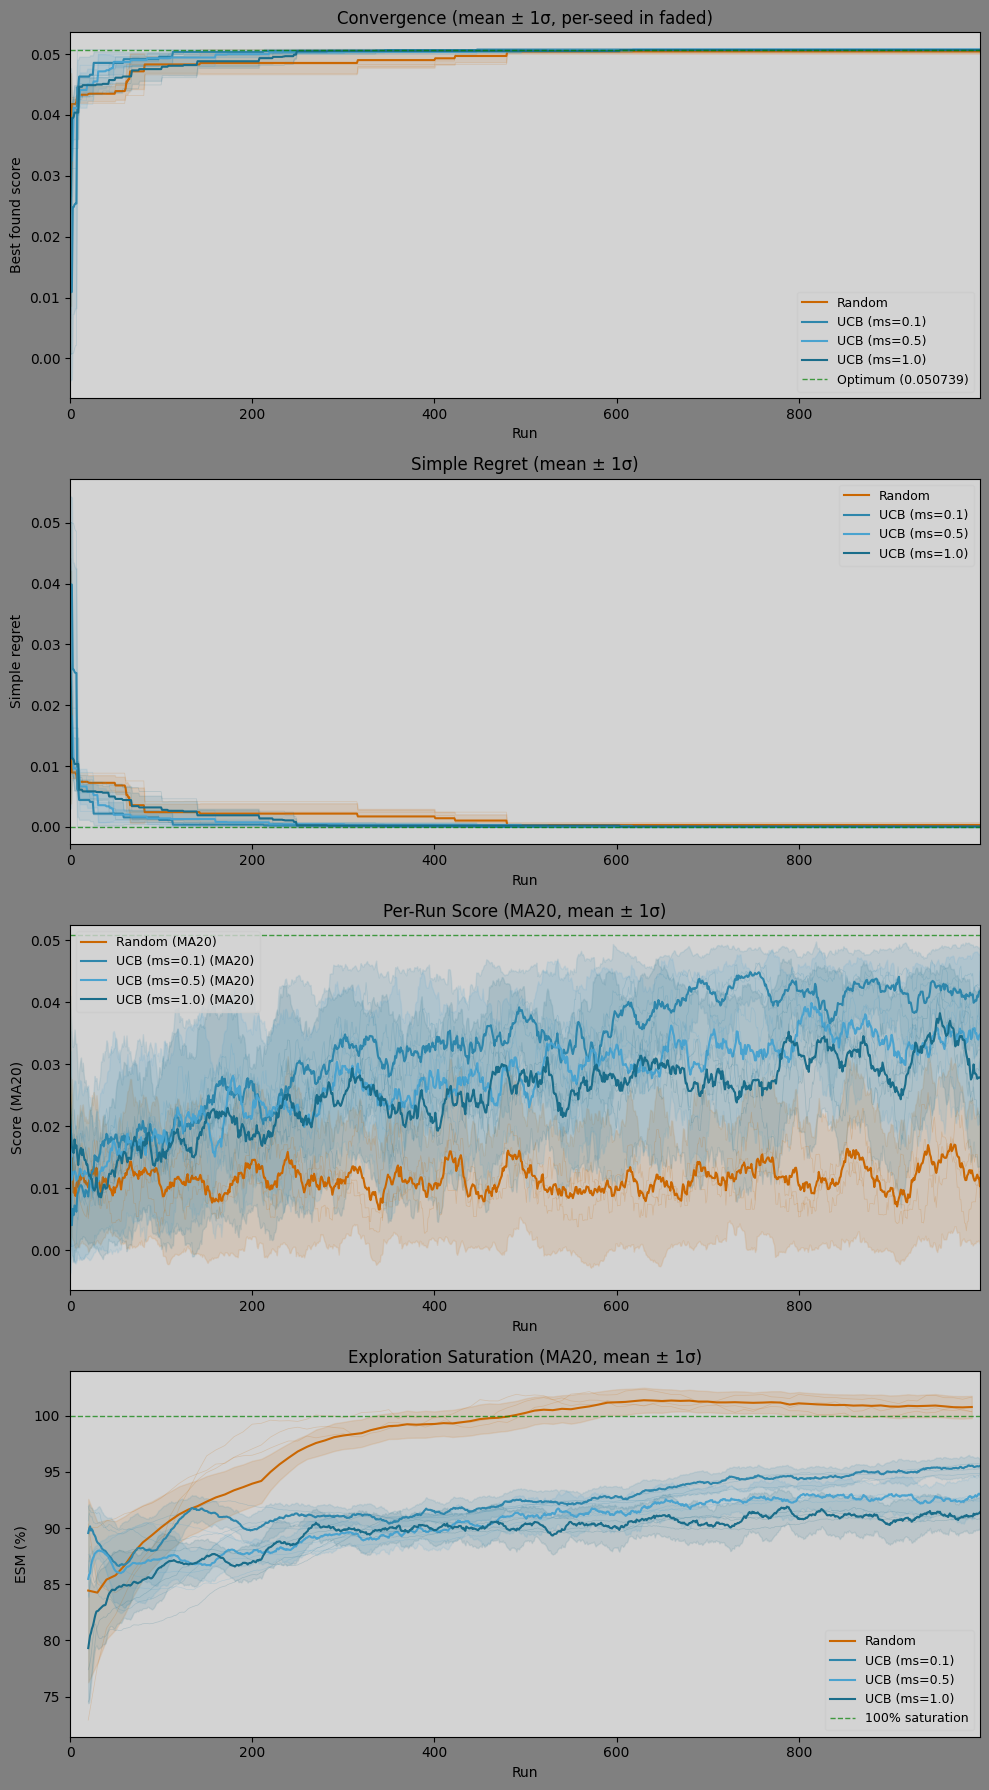

In [10]:
from matplotlib.figure import Figure
from matplotlib.axes import Axes

fig: Figure
axes: list[Axes]
fig, axes = plt.subplots(4, 1, figsize=(10, 18))

CONFIGS = [
    {"strategy": "random", "max_samples": 0.1, "label": "Random",             "color": "#ca6702"},
    {"strategy": "ucb",    "max_samples": 0.1, "label": "UCB (ms=0.1)",       "color": "#2e86ab"},
    {"strategy": "ucb",    "max_samples": 0.5, "label": "UCB (ms=0.5)",       "color": "#4aa3cf"},
    {"strategy": "ucb",    "max_samples": 1.0, "label": "UCB (ms=1.0)",       "color": "#1a6d8a"},
]

global_optimum = best_score
seeds = sorted(all_trajectories["seed"].unique().to_list())
n_runs_plot = all_trajectories["run"].max() + 1

# Aggregate across seeds per config per run
aggregated = (
    all_trajectories
    .group_by(["strategy", "max_samples", "run"])
    .agg([
        pl.col("best_found").mean().alias("bf_mean"),
        pl.col("best_found").std(ddof=0).alias("bf_std"),
        pl.col("simple_regret").mean().alias("sr_mean"),
        pl.col("simple_regret").std(ddof=0).alias("sr_std"),
        pl.col("score").mean().alias("score_mean"),
        pl.col("score").std(ddof=0).alias("score_std"),
        pl.col("esm").drop_nulls().mean().alias("esm_mean"),
        pl.col("esm").drop_nulls().std(ddof=0).alias("esm_std"),
    ])
    .sort(["strategy", "max_samples", "run"])
)

def filter_config(data, config):
    return data.filter(
        (pl.col("strategy") == config["strategy"]) &
        (pl.col("max_samples") == config["max_samples"])
    )

# Plot 1: Best found over runs
ax: Axes = axes[0]
for config in CONFIGS:
    agg = filter_config(aggregated, config).sort("run")
    seed_trajs = filter_config(all_trajectories, config)
    for seed in seeds:
        traj = seed_trajs.filter(pl.col("seed") == seed).sort("run")
        ax.plot(traj["run"], traj["best_found"], color=config["color"], linewidth=0.5, alpha=0.2)
    ax.plot(agg["run"], agg["bf_mean"], label=config["label"], color=config["color"], linewidth=1.5)
    ax.fill_between(agg["run"], agg["bf_mean"] - agg["bf_std"], agg["bf_mean"] + agg["bf_std"],
                     color=config["color"], alpha=0.12)
ax.axhline(global_optimum, color="green", linestyle="--", linewidth=1, alpha=0.7, label=f"Optimum ({global_optimum:.6f})")
ax.set_xlabel("Run")
ax.set_ylabel("Best found score")
ax.set_title("Convergence (mean ± 1σ, per-seed in faded)")
ax.legend(fontsize=9)
ax.set_xlim(0, n_runs_plot - 1)

# Plot 2: Simple regret over runs
ax = axes[1]
for config in CONFIGS:
    agg = filter_config(aggregated, config).sort("run")
    seed_trajs = filter_config(all_trajectories, config)
    for seed in seeds:
        traj = seed_trajs.filter(pl.col("seed") == seed).sort("run")
        ax.plot(traj["run"], traj["simple_regret"], color=config["color"], linewidth=0.5, alpha=0.2)
    ax.plot(agg["run"], agg["sr_mean"], label=config["label"], color=config["color"], linewidth=1.5)
    ax.fill_between(agg["run"], agg["sr_mean"] - agg["sr_std"], agg["sr_mean"] + agg["sr_std"],
                     color=config["color"], alpha=0.12)
ax.axhline(0, color="green", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Run")
ax.set_ylabel("Simple regret")
ax.set_title("Simple Regret (mean ± 1σ)")
ax.legend(fontsize=9)
ax.set_xlim(0, n_runs_plot - 1)

# Plot 3: Per-run score with rolling mean
ax = axes[2]
score_window = 20
for config in CONFIGS:
    agg = filter_config(aggregated, config).sort("run")
    seed_trajs = filter_config(all_trajectories, config)
    for seed in seeds:
        traj = seed_trajs.filter(pl.col("seed") == seed).sort("run")
        rolling_seed = traj.select(
            pl.col("score").rolling_mean(window_size=score_window, min_samples=1)
        ).to_series().to_numpy()
        ax.plot(traj["run"], rolling_seed, color=config["color"], linewidth=0.5, alpha=0.2)
    rolling_mean = agg.select(
        pl.col("score_mean").rolling_mean(window_size=score_window, min_samples=1)
    ).to_series().to_numpy()
    rolling_std = agg.select(
        pl.col("score_std").rolling_mean(window_size=score_window, min_samples=1)
    ).to_series().to_numpy()
    ax.plot(agg["run"], rolling_mean, label=f"{config['label']} (MA{score_window})", color=config["color"], linewidth=1.5)
    ax.fill_between(agg["run"], rolling_mean - rolling_std, rolling_mean + rolling_std,
                     color=config["color"], alpha=0.12)
ax.axhline(global_optimum, color="green", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Run")
ax.set_ylabel("Score (MA20)")
ax.set_title(f"Per-Run Score (MA{score_window}, mean ± 1σ)")
ax.legend(fontsize=9)
ax.set_xlim(0, n_runs_plot - 1)

# Plot 4: ESM over runs
ax = axes[3]
esm_window = 20
for config in CONFIGS:
    seed_trajs = filter_config(all_trajectories, config)
    for seed in seeds:
        traj = seed_trajs.filter(pl.col("seed") == seed).sort("run")
        esm_data = traj.filter(pl.col("esm").is_not_null())
        if len(esm_data) > 0:
            rolling_esm_seed = esm_data.select(
                pl.col("esm").rolling_mean(window_size=max(1, len(esm_data) // 10), min_samples=1)
            ).to_series().to_numpy()
            ax.plot(esm_data["run"], rolling_esm_seed, color=config["color"], linewidth=0.5, alpha=0.2)
    agg_esm = filter_config(aggregated, config).filter(pl.col("esm_mean").is_not_null()).sort("run")
    if len(agg_esm) > 0:
        rolling_esm = agg_esm.select(
            pl.col("esm_mean").rolling_mean(window_size=esm_window, min_samples=1)
        ).to_series().to_numpy()
        rolling_esm_std = agg_esm.select(
            pl.col("esm_std").rolling_mean(window_size=esm_window, min_samples=1)
        ).to_series().to_numpy()
        ax.plot(agg_esm["run"], rolling_esm, label=config["label"], color=config["color"], linewidth=1.5)
        ax.fill_between(agg_esm["run"], rolling_esm - rolling_esm_std, rolling_esm + rolling_esm_std,
                         color=config["color"], alpha=0.12)
ax.axhline(100, color="green", linestyle="--", linewidth=1, alpha=0.7, label="100% saturation")
ax.set_xlabel("Run")
ax.set_ylabel("ESM (%)")
ax.set_title("Exploration Saturation (MA20, mean ± 1σ)")
ax.legend(fontsize=9)
ax.set_xlim(0, n_runs_plot - 1)

plt.tight_layout()
plt.show()